In [1]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')

### COMBINATORIAL (Bush et al., 2015)

In [2]:
class ParentNNClass():

    def __init__(self, M = 10, s_M = 25, alpha = 1.4, m = 20, r_max = 30, time_w = 0.1):
        self.M = M          # Number of GC modules
        self.s_M = s_M      # Minimum grid scale (for geometric progression)
        self.alpha = alpha  # Common factor (for geometric progression)
        self.m = m          # Number of equally distributes spatial phases
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()

    def _create_scales(self):
        ''' Creates M scales according to geometric progression '''
        scales = []
        for i in np.arange(self.M, 0, -1):
            new_scale = round(self.s_M * (self.alpha ** (self.M-i)),2)
            scales.append(new_scale)
        return scales

    def _create_phases(self):
        ''' Creates m equally spaced phases from 0 to 2*pi in radians'''
        return np.linspace(0, 2 * np.pi, self.m, endpoint=False)
    
    def _gc_rate(self, a, s_i, p_ij):
        ''' Calculates GC firing rate based on cosine tuned rate function '''
        num_bracket = (a - (s_i * (p_ij / (2 * np.pi)))) / s_i
        return self.r_max * (1 + np.cos(num_bracket * 2 * np.pi)) / 2
    
    def emax_N_normalize(self, x, epsilon=0.01):
        ''' Applies E%-max algorithm and normalzation steps '''
        # E%-max algorithm: silence all values below (1-epsilon) of the maximum value
        threshold = x.max() * (1 - epsilon)
        dc_activations = np.where(x >= threshold, x, 0.0)

        # Normalize so total activity is constant across simulations
        total = dc_activations.sum()
        if total > 0:
            dc_activations = dc_activations / total
        return dc_activations


class DistanceCellModel(ParentNNClass):
    
    # Call the parent class constructor to initialize the parameters
    def __init__(self, N_dc = 12500, dc_res = 4, **kwargs):
        super().__init__(**kwargs)  # Call the parent class constructor
        self.N_dc = N_dc        # Number of distance cells
        self.dc_res = dc_res    # Spatial resolution of distance cells (cm)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xdc_positions = self._create_distance_cells()
        self.W_dcs = self._compute_weight_matrix()   # We use same W matrix for both x and y axes (for a total of 200 x 2 = 400 grid cells)
        self.W_pos_readout = self.xdc_positions / self.xdc_positions.max()  # Increases linearly with displacement along axis
        self.W_neg_readout = self.W_pos_readout.copy()[::-1]              # Decreases linearly (to encode opposite direction)


    def _create_distance_cells(self):
        ''' Creates N_dc distance cell according to spatial resolution '''
        return np.arange(0, self.N_dc * self.dc_res, self.dc_res)
    
    def _compute_weight_matrix(self):
        ''' For each distance cell a, compute rate of cell j at scale i (i.e., r_ij) '''
        all_weights = []
        for curr_distance in self.xdc_positions:
            distance_weights = []
            for s_i in self.scales:
                for p_ij in self.phases:
                    r_ij = self._gc_rate(curr_distance, s_i, p_ij)
                    distance_weights.append(r_ij)
            all_weights.append(distance_weights)
        return np.array(all_weights)
    
    def _gc_spikes(self, a):
        ''' Given current 2D position a, calculate GC spikes for all GCs in our network along axes x and y
            Returns a 2D array of shape (2, M*m) = (axes, modules * phases) with the number of spikes for each GC
        '''
        x_gc_spikes = []
        y_gc_spikes = []
        for s_i in self.scales:
            for p_i in self.phases:
                r_ix = self._gc_rate(a[0], s_i, p_i) # FR at x-axis
                r_iy = self._gc_rate(a[1], s_i, p_i) # FR at y-axis
                spikes_ix = np.random.poisson(lam = self.poiss_time_w * r_ix)
                spikes_iy = np.random.poisson(lam = self.poiss_time_w * r_iy)
                #print(f"GC at phase {p_ij} with rate {np.round(r_ij)}: spikes: {spikes_ij}")
                x_gc_spikes.append(spikes_ix)
                y_gc_spikes.append(spikes_iy)
        return np.array([x_gc_spikes, y_gc_spikes])

    def forward(self, a, b):
        ''' Given current 2D position a and target position b, apply forward pass by 
            1) calculating GC spikes
            2) multiplying it with the network weights
            3) applying E%-max algorithm & normalization step
        '''

        # 1. Calculate spikes for all GCs in our network start & goal positions
        start_gc_activations = self._gc_spikes(a)
        goal_gc_activations = self._gc_spikes(b)

        # 2. Compute forward passes
        start_xdc_activations = self.emax_N_normalize(self.W_dcs @ start_gc_activations[0])
        start_ydc_activations = self.emax_N_normalize(self.W_dcs @ start_gc_activations[1])
        goal_xdc_activations = self.emax_N_normalize(self.W_dcs @ goal_gc_activations[0])
        goal_ydc_activations = self.emax_N_normalize(self.W_dcs @ goal_gc_activations[1])

        # 3. Read-out cells
        x_read_out_one = self.W_neg_readout @ start_xdc_activations + self.W_pos_readout @ goal_xdc_activations
        x_read_out_two = self.W_pos_readout @ start_xdc_activations + self.W_neg_readout @ goal_xdc_activations
        x_read_out_diff = x_read_out_one - x_read_out_two
        
        y_read_out_one = self.W_neg_readout @ start_ydc_activations + self.W_pos_readout @ goal_ydc_activations
        y_read_out_two = self.W_pos_readout @ start_ydc_activations + self.W_neg_readout @ goal_ydc_activations
        y_read_out_diff = y_read_out_one - y_read_out_two

        decoded_position = np.array([x_read_out_diff, y_read_out_diff]) * (self.xdc_positions.max()/2) # Convert back to cm - need division to account for four weights
        return decoded_position
    
  
dc_model = DistanceCellModel()
print(dc_model.forward(a=[250, 250], b=[258, 258]))
# Print different edge cases
#print(dc_model.forward(a=[0, 0], b=[500, 500]))
#print(dc_model.forward(a=[500, 500], b=[0, 0]))
#print(dc_model.forward(a=[250, 250], b=[250, 250]))
#print(dc_model.forward(a=[0, 500], b=[500, 0]))

[7.991209   6.00389639]


In [3]:
class VectorCellModel2(ParentNNClass):

    def __init__(self, N_fvc = 12500, N_cvc = 1250, arena_max = 50000, **kwargs):
        super().__init__(**kwargs)  # Call the parent class constructor
        self.N_fvc = N_fvc    # Number of "fine-grained" vector cells per array (x or y, pos or neg)
        self.N_cvc = N_cvc    # Number of "course-grained" vector cells per array (x or y, pos or neg)
        self.arena_max = arena_max  # cm

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()

        self.fvc_pos = self._create_fine_vector_cells()
        self.cvc_pos = self._create_coarse_vector_cells()

        self.W_phasediff = self._compute_phasediff_weight_matrix()
        self.W_GCtoFVC = self._compute_GCtoFVC_weight_matrix()
        self.W_FVCtoCVC = self._compute_FVCtoCVC_weight_matrix()

    def _create_fine_vector_cells(self):
        ''' "Fine-grained" linearly spaced cells, not mentioned in paper. '''
        return np.linspace(0, self.arena_max, self.N_fvc)

    def _create_coarse_vector_cells(self):
        ''' Pseudo-exponential distribution of translation vectors encoded by vector cells. '''
        c_vcs = [0]
        for s_i in self.scales:
            segment = np.linspace(
                s_i * (self.arena_max / (sum(self.scales) * 100)),
                s_i * self.arena_max / sum(self.scales),
                round(self.N_cvc / len(self.scales))
            )
            c_vcs.extend(c_vcs[-1] + segment)
        return np.array(c_vcs)

    def _compute_phasediff_weight_matrix(self):
        Grid_Vec_w = np.zeros((self.m, self.m, self.m))
        for offset in range(self.m):
            for vec in range(self.m):
                syn = (offset + vec) % self.m  # circular shift (0-indexed, so no -1+1)
                Grid_Vec_w[offset, syn, vec] = 5e-4
        return Grid_Vec_w

    def _compute_GCtoFVC_weight_matrix(self):
        Wgc_fvc = np.zeros((self.m, self.N_fvc, len(self.scales)))
        for i, s_i in enumerate(self.scales):
            for offset in range(self.m):
                Wgc_fvc[offset, :, i] = (np.cos((np.mod(self.fvc_pos - (offset / self.m) * s_i, s_i) / s_i) * 2 * np.pi) + 1) / 2 * 5e-4
        return Wgc_fvc

    def _compute_FVCtoCVC_weight_matrix(self):
        Wfvc_cvc = np.zeros((self.N_fvc, len(self.cvc_pos)))
        for c in range(len(self.fvc_pos)):
            ind = np.argmin(np.abs(self.fvc_pos[c] - self.cvc_pos))
            Wfvc_cvc[c, ind] = 1
        return Wfvc_cvc

    def _gc_pair_spikes(self, a, b):
        '''
        Given 1-D start position a and goal position b, compute the multiplicative GC output for each scale along each axis.
        Returns two arrays of shape (m, M) — the m phase-difference slots activated by the start x goal outer product, for each scale.
        '''
        multsyn_pos = np.zeros((self.m, self.M))  # positive direction
        multsyn_neg = np.zeros((self.m, self.M))  # negative direction

        for i, s_i in enumerate(self.scales):

            # Compute mean firing rates for each of the m GCs at start and goal, on each axis
            # Using index k directly as phase proxy (equivalent to Eq S6)
            start_rates = np.array([self._gc_rate(a, s_i, p) * self.poiss_time_w for p in self.phases])
            goal_rates = np.array([self._gc_rate(b, s_i, p) * self.poiss_time_w for p in self.phases])

            # Sample Poisson spikes
            start_spikes = np.random.poisson(start_rates)  # shape (m,)
            goal_spikes  = np.random.poisson(goal_rates)
    
            # Compute multiplicative synapse output via Grid_Vec_w
            # einsum: outer product (m, m) contracted with Grid_Vec_w (m, m, m) -> (m,)
            multsyn_pos[:, i] = np.einsum('ij,ijv->v', np.outer(start_spikes, goal_spikes), self.W_phasediff)
            multsyn_neg[:, i] = np.einsum('ij,ijv->v', np.outer(goal_spikes, start_spikes), self.W_phasediff)

        return multsyn_pos, multsyn_neg

    
    def forward(self, a, b):
        ''' Given current 2D position a and target position b, apply forward pass by 
            1) calculating GC spikes
            2) multiplying it with the network weights
            3) applying E%-max algorithm & normalization step
        '''

        # 1. Calculate spikes for all GCs in our network start & goal positions
        gc_x_pos, gc_x_neg = self._gc_pair_spikes(a[0], b[0])
        gc_y_pos, gc_y_neg = self._gc_pair_spikes(a[1], b[1])

        # 2. Project onto "fine-grained" vector cells
        fvc_x_pos, fvc_x_neg = np.zeros(self.N_fvc), np.zeros(self.N_fvc)
        fvc_y_pos, fvc_y_neg = np.zeros(self.N_fvc), np.zeros(self.N_fvc)
        for i in range(len(self.scales)):
            fvc_x_pos += gc_x_pos[:, i] @ self.W_GCtoFVC[:, :, i] 
            fvc_x_neg += gc_x_neg[:, i] @ self.W_GCtoFVC[:, :, i] 
            fvc_y_pos += gc_y_pos[:, i] @ self.W_GCtoFVC[:, :, i] 
            fvc_y_neg += gc_y_neg[:, i] @ self.W_GCtoFVC[:, :, i] 

        #3. Contatenate, conduct E-max + normalization step, and split back
        fvc_x = self.emax_N_normalize(np.concatenate([fvc_x_pos, fvc_x_neg]))
        fvc_y = self.emax_N_normalize(np.concatenate([fvc_y_pos, fvc_y_neg]))
        fvc_x_pos, fvc_x_neg = fvc_x[:self.N_fvc], fvc_x[self.N_fvc:]
        fvc_y_pos, fvc_y_neg = fvc_y[:self.N_fvc], fvc_y[self.N_fvc:]

       # 4. Project onto "coarse-grained" vector cells
        cvc_x_pos = fvc_x_pos @ self.W_FVCtoCVC  
        cvc_x_neg = fvc_x_neg @ self.W_FVCtoCVC
        cvc_y_pos = fvc_y_pos @ self.W_FVCtoCVC
        cvc_y_neg = fvc_y_neg @ self.W_FVCtoCVC

        # 5. Decode: weighted mean of active coarse VCs, pos direction minus neg
        x_decoded = np.nanmean(np.concatenate([self.cvc_pos[cvc_x_pos > 0],-self.cvc_pos[cvc_x_neg > 0]]))
        y_decoded = np.nanmean(np.concatenate([self.cvc_pos[cvc_y_pos > 0],-self.cvc_pos[cvc_y_neg > 0]]))

        return np.array([x_decoded, y_decoded])


vc_model = VectorCellModel2()
vec = vc_model.forward(a=[240, 250], b=[200, 270])
print('vec', vec)
'''
tr_vec = vc_model.forward(a=[250, 250], b=[260, 260])
print('Expected translation vector around [20, 20]. Model translation vector:', tr_vec)
print(vc_model.xvc_pos[:10])   # first 10 vc positions
print(vc_model.xvc_pos[-10:])  # last 10 vc positions
print(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs
print(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs
'''


vec [-41.46963776  18.59780412]


"\ntr_vec = vc_model.forward(a=[250, 250], b=[260, 260])\nprint('Expected translation vector around [20, 20]. Model translation vector:', tr_vec)\nprint(vc_model.xvc_pos[:10])   # first 10 vc positions\nprint(vc_model.xvc_pos[-10:])  # last 10 vc positions\nprint(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs\nprint(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs\n"

In [38]:
syn_index = 8
only_active_syns = True
print(f'Analyzing synapse index {syn_index} for VC activations:')
for vc_i, vc in enumerate(vc_model.Wpos[:,syn_index]):
    curr_xpos = round(vc_model.xvc_pos[vc_i], 2)
    if only_active_syns and not vc > 0:
        continue
    print(f"VC{vc_i}: {curr_xpos} \t synapse: {vc}")

Analyzing synapse index 8 for VC activations:
VC7: 9.64 	 synapse: 0.010309278350515464
VC25: 35.7 	 synapse: 0.010309278350515464
VC41: 60.5 	 synapse: 0.010309278350515464
VC56: 85.24 	 synapse: 0.010309278350515464
VC70: 109.7 	 synapse: 0.010309278350515464
VC84: 135.58 	 synapse: 0.010309278350515464
VC97: 160.94 	 synapse: 0.010309278350515464
VC109: 185.55 	 synapse: 0.010309278350515464
VC120: 209.17 	 synapse: 0.010309278350515464
VC142: 259.66 	 synapse: 0.010309278350515464
VC152: 284.12 	 synapse: 0.010309278350515464
VC162: 309.57 	 synapse: 0.010309278350515464
VC181: 360.84 	 synapse: 0.010309278350515464
VC198: 410.14 	 synapse: 0.010309278350515464
VC206: 434.53 	 synapse: 0.010309278350515464
VC214: 459.71 	 synapse: 0.010309278350515464
VC222: 485.71 	 synapse: 0.010309278350515464
VC229: 509.15 	 synapse: 0.010309278350515464
VC257: 609.77 	 synapse: 0.010309278350515464
VC270: 660.47 	 synapse: 0.010309278350515464
VC276: 684.77 	 synapse: 0.010309278350515464
VC28

In [ ]:
s_i = 0
print('---Scale:', vc_model.scales[s_i])
for i in range(vc_model.xvc_pos.shape[0]):
    w_i = vc_model.W_vcs[i, s_i, 20]
    if w_i > 0:
        print(f"VC Position = {round(vc_model.xvc_pos[i], 2)} \t w = {w_i}")  


---Scale: 25.0


AttributeError: 'VectorCellModel' object has no attribute 'W_vcs'

Simulation

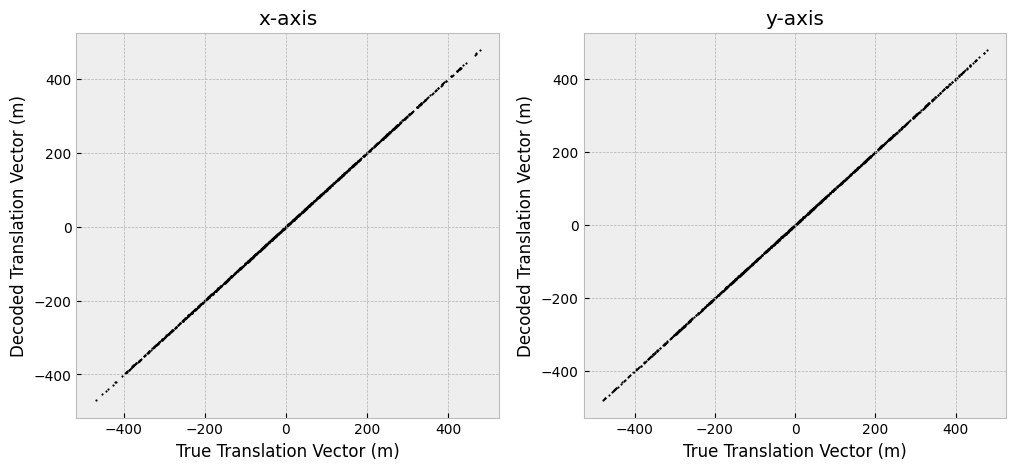

In [5]:
def simulation(model, N=1000, arena_width = 50000):
    a_s = [np.random.rand(N) * arena_width for _ in range(2)]
    b_s = [np.random.rand(N) * arena_width for _ in range(2)]
    b_hats = []
    for i in range(N):
        b_hats.append(model.forward(a=[a_s[0][i], a_s[1][i]], b=[b_s[0][i], b_s[1][i]]))
    b_hats = np.array(b_hats)

    # Plot two plots for x and y
    plt.subplots(1, 2, figsize=(12, 5))
    for i in range(2):
        plt.subplot(1, 2, i+1)
        plt.scatter((b_s[i] - a_s[i]) / 100, b_hats[:, i] / 100, color='black', s=1)
        plt.xlabel('True Translation Vector (m)')
        plt.ylabel('Decoded Translation Vector (m)')
        curr_axis = 'x' if i == 0 else 'y'
        plt.title(f'{curr_axis}-axis')

simulation(DistanceCellModel())

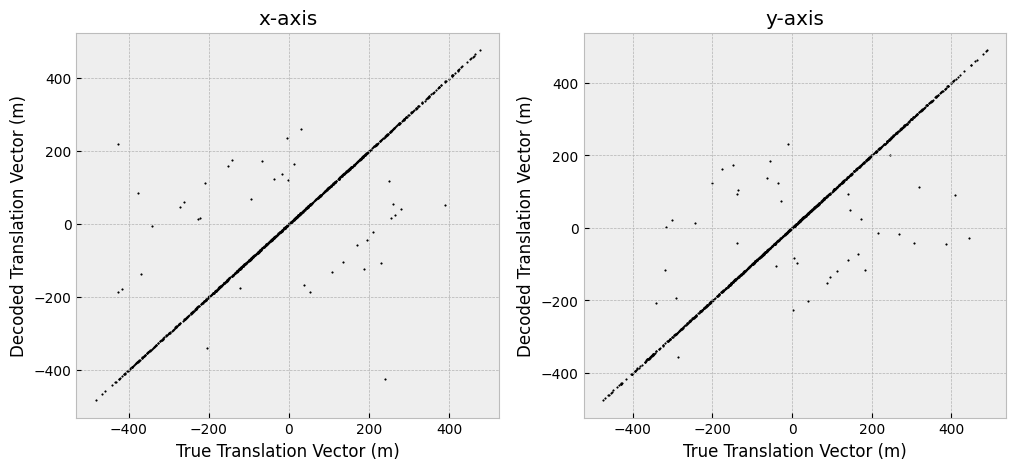

In [6]:
simulation(VectorCellModel2())

### NESTED (Stemmler et al., 2015)

In [ ]:
lambda_j = 50
omega = (2 * np.pi) / (np.sin(np.pi / 3) * lambda_j)

def k_vec(l):
    phi_l = - (np.pi / 6) + (l * np.pi / 3)
    return np.array([np.cos(phi_l), np.sin(phi_l)])

def f(x_vec, l=1):
    return np.cos((omega * k_vec(l)) @ x_vec)

f([0,1])

0.9973692597686135

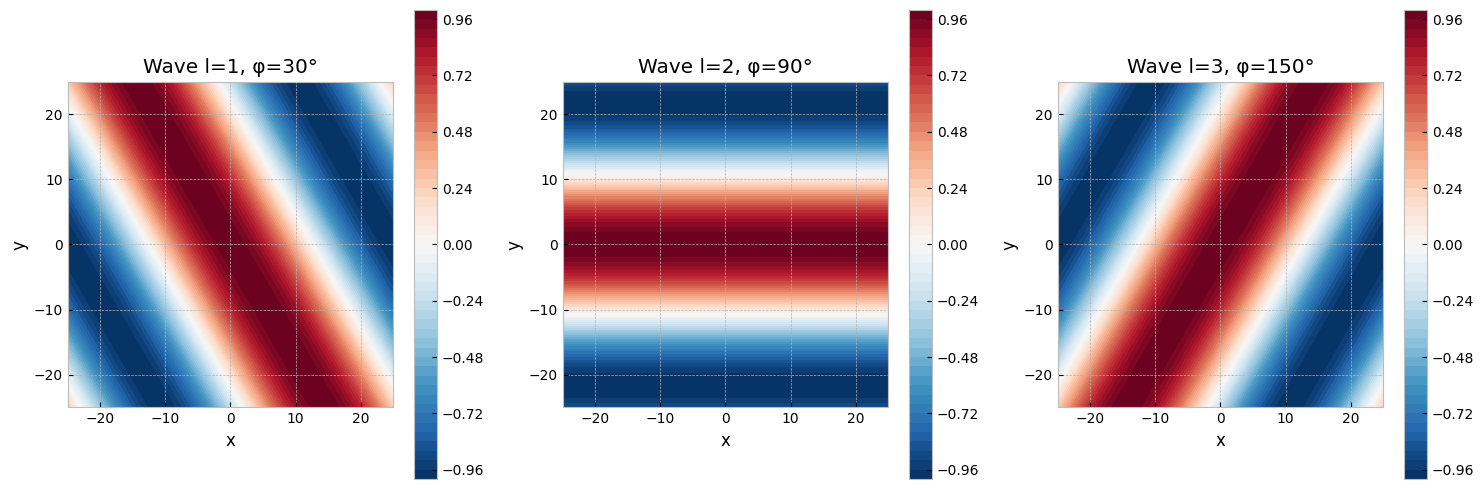

In [ ]:

def f(X, Y, l=1):
    ''' Vectorized: X, Y are meshgrid arrays '''
    kx, ky = k_vec(l)
    return np.cos(omega * (kx * X + ky * Y))

xs = np.linspace(-25, 25, 50)
ys = np.linspace(-25, 25, 50)
X, Y = np.meshgrid(xs, ys)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, l in enumerate([1, 2, 3]):
    Z = f(X, Y, l=l)
    im = axes[i].contourf(X, Y, Z, levels=50, cmap='RdBu_r')
    axes[i].set_title(f'Wave l={l}, φ={np.degrees(-(np.pi/6) + l*np.pi/3):.0f}°')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].set_aspect('equal')
    fig.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

In [33]:
0.3 * np.sum([1,1,1])

0.8999999999999999

In [42]:
class NestedModel():

    def __init__(self, M = 10, m = 20, arena_max = 50, r_max = 30, time_w = 0.1, scale_ratio=1.5):
        self.M = M          # Number of GC modules
        self.m = m          # Number of equally distributed spatial phases
        self.arena_max = arena_max  # cm
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)
        self.scale_ratio = scale_ratio   # s = lambda_i / lambda_{i+1}, paper's optimum ≈ 3/2

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()

    def _create_scales(self):
        ''' Creates M module scales as a geometric progression
        '''
        return self.arena_max / (self.scale_ratio ** np.arange(self.M))

    def _create_phases(self):
        ''' Creates m equally spaced phases for each scale'''
        return [np.linspace(0, scale, self.m, endpoint=False) for scale in self.scales]
    
    # --- Grid cell expected firing rate for 1D and 2D cases ---
    def _gc_rate_1D(self, a, lambda_j,  c_j, kappa=1):
        ''' Calculates GC firing rate based on von Mises function for 1D case.
            a=current position
            c_j=spatial phase
            lambda_j=spatial period
            kappa=?
           '''
        return self.r_max * np.exp(kappa * (np.cos(2 * np.pi * (a - c_j) / lambda_j) - 1))
    
    def k_vec(l):
        ''' Wave vector used to reconstruct hexagonal lattice '''
        phi_l = - (np.pi / 6) + (l * np.pi / 3)
        return np.array([np.cos(phi_l), np.sin(phi_l)])

    def _gc_rate_2D(self, a, lambda_j, c_j, kappa=1):
        ''' Calculates GC firing rate based on von Mises function for 2D case.
            a=2D current position
            lambda_j=spatial period
            c_j=2D spatial phases
            kappa=relative tuning width
           '''
        a = np.array(a)
        c_j = np.array(c_j)
        omega = (2 * np.pi) / (np.sin(np.pi / 3) * lambda_j)
        return self.r_max * np.exp((kappa/3) * np.sum([np.cos((omega * k_vec(l)) @ (a - c_j)) - 1 for l in [1,2,3]]))
    
    # --- Grid cell spiking function ---
    def _gc_spikes(self, a):
        ''' Computes GC spikes following Poisson process
        '''
        ndim = 1 if isinstance(a,int) else 2
        gc_spikes = []
        for lambda_i_idx, lambda_i in enumerate(self.scales):
            scale_gc_spikes = []
            scale_phases = self.phases[lambda_i_idx]
            for c_j in scale_phases:
                if ndim == 1:
                    r_j = self._gc_rate_1D(a, lambda_i, c_j) # FR at x-axis
                elif ndim == 2:
                    r_j = self._gc_rate_2D(a, lambda_i, c_j) # FR considering both x- and y-axes
                spikes_j = np.random.poisson(lam = self.poiss_time_w * r_j)
                scale_gc_spikes.append(spikes_j)
            gc_spikes.append(scale_gc_spikes)
        return np.array(gc_spikes)
    
    # --- Population vector functions ---
    def _phasor(self, c_j, lambda_i):
        ''' Returns phasor of given spatial phase '''
        theta = 2 * np.pi * c_j / lambda_i
        return np.cos(theta) + np.sin(theta) * 1j
    
    def population_vector_1D(self, a):
        ''' Computes population vector using nested approach according to eqs. 2 & 3 in Stemmler. et al (2015)
        '''
        # 1. Get spikes for current location
        spikes = self._gc_spikes(a[0])
        print('For position=',a[0])
        #2. Follow nested decoding method to obtain population vector
        lambda_i_idx = 0
        lambda_i = self.scales[lambda_i_idx]
        curr_sum = np.sum([spikes[lambda_i_idx][j] * self._phasor(c_j, lambda_i) for j,c_j in enumerate(self.phases[lambda_i_idx])])
        curr_x_est = (lambda_i / (2 * np.pi)) * np.angle(curr_sum)
        print('lambda_i_idx:',lambda_i_idx,'lambda_i:',lambda_i, 'curr_x_est:',curr_x_est)
        cum_precision = self.m * lambda_i**-2  
        for lambda_i_idx in np.arange(1, len(self.scales)):
            lambda_i = self.scales[lambda_i_idx]
            precision_i = self.m * lambda_i**-2
            eta_tilde = precision_i / (cum_precision + precision_i)
            curr_sum = np.sum([spikes[lambda_i_idx][j] * self._phasor(c_j, lambda_i) for j,c_j in enumerate(self.phases[lambda_i_idx])])
            curr_x_est += eta_tilde * (lambda_i / (2 * np.pi)) * np.angle(self._phasor(-curr_x_est, lambda_i) * curr_sum)
            print('lambda_i_idx:',lambda_i_idx,'lambda_i:',lambda_i, 'curr_x_est:',curr_x_est)
            cum_precision += precision_i
        return curr_x_est

    def population_vector_2D(self, a):
        ''' Computes population vector using nested approach according to eq. 6 in Stemmler. et al (2015)
        '''
        # 1. Get spikes for current location
        spikes = self._gc_spikes(a)
        print(spikes)
    
nm = NestedModel()
#nm.population_vector_1D([15,0])
#nm.population_vector_1D([23,0])
#nm.population_vector_1D([0,0])
#nm.population_vector_1D([48,0])
nm.population_vector_2D([0,0])


[[0 3 4 4 2 1 0 0 0 3 3 0 0 0 0 1 0 1 1 0]
 [2 2 0 0 1 1 0 2 0 0 0 0 0 1 0 1 0 0 1 1]
 [1 2 5 3 2 0 0 1 1 1 1 1 3 0 4 0 2 1 0 2]
 [0 6 3 2 2 0 1 1 1 0 4 0 1 3 1 2 0 3 2 0]
 [1 1 3 2 0 2 1 0 2 3 3 2 2 1 0 1 2 2 0 1]
 [1 6 2 2 3 1 0 2 2 1 1 2 1 1 0 0 4 1 0 0]
 [0 1 1 2 3 0 1 0 1 0 0 1 0 1 3 0 2 0 0 2]
 [0 1 0 0 1 1 1 0 4 1 1 1 0 0 2 2 1 2 2 0]
 [1 2 2 2 1 0 2 0 3 2 1 0 0 2 2 0 0 0 1 0]
 [2 3 4 1 2 1 2 0 0 0 0 1 2 2 1 3 3 1 1 0]]


In [27]:
for j,c_j in enumerate(nm.phases[0]):
    print(j,c_j)

0 0.0
1 2.5
2 5.0
3 7.5
4 10.0
5 12.5
6 15.0
7 17.5
8 20.0
9 22.5
10 25.0
11 27.5
12 30.0
13 32.5
14 35.0
15 37.5
16 40.0
17 42.5
18 45.0
19 47.5


In [23]:
np.cos(1) + np.sin(1)*1j

(0.5403023058681397+0.8414709848078965j)

In [18]:
nm.phases

[array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. , 22.5, 25. ,
        27.5, 30. , 32.5, 35. , 37.5, 40. , 42.5, 45. , 47.5]),
 array([ 0.  ,  2.25,  4.5 ,  6.75,  9.  , 11.25, 13.5 , 15.75, 18.  ,
        20.25, 22.5 , 24.75, 27.  , 29.25, 31.5 , 33.75, 36.  , 38.25,
        40.5 , 42.75]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
        26., 28., 30., 32., 34., 36., 38.]),
 array([ 0.  ,  1.75,  3.5 ,  5.25,  7.  ,  8.75, 10.5 , 12.25, 14.  ,
        15.75, 17.5 , 19.25, 21.  , 22.75, 24.5 , 26.25, 28.  , 29.75,
        31.5 , 33.25]),
 array([ 0. ,  1.5,  3. ,  4.5,  6. ,  7.5,  9. , 10.5, 12. , 13.5, 15. ,
        16.5, 18. , 19.5, 21. , 22.5, 24. , 25.5, 27. , 28.5]),
 array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.  ,
        11.25, 12.5 , 13.75, 15.  , 16.25, 17.5 , 18.75, 20.  , 21.25,
        22.5 , 23.75]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18

### OLD CODE

In [ ]:
# Original init method with all parameters

def __init__(self, M = 10, s_M = 25, alpha = 1.4, m = 20, r_max = 30, N_dc = 12500, dc_res = 4, time_w = 0.1):
        super().__init__(M, s_M, alpha, m, r_max, time_w)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.alpha = alpha  # Common factor (for geometric progression)
        self.m = m          # Number of equally distributes spatial phases
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xdc_positions = self._create_distance_cells()
        self.W_dcs = self._compute_weight_matrix()  
        self.W_pos_readout = self.xdc_positions / self.xdc_positions.max()  # Increases linearly with displacement along axis
        self.W_neg_readout = self.W_pos_readout.copy()[::-1]              # Decreases linearly (to encode opposite direction)

In [ ]:
class VectorCellModel(ParentNNClass):

    def __init__(self, N_vc = 1250, arena_max = 50000, **kwargs):
        super().__init__(**kwargs)  # Call the parent class constructor
        self.N_vc = N_vc    # Number of vector cells per array (x or y, pos or neg)
        self.arena_max = arena_max  # cm

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xvc_pos = self._create_vector_cells(direction='positive')
        self.xvc_neg = self._create_vector_cells(direction='negative')
        self.xvcs = np.concatenate((self.xvc_pos, self.xvc_neg))
        self.yvc_pos = self._create_vector_cells(direction='positive')
        self.yvc_neg = self._create_vector_cells(direction='negative')
        self.yvcs = np.concatenate((self.yvc_pos, self.yvc_neg))
        self.Wpos = self._compute_weight_matrix(direction='positive')   
      #  self.Wneg = self._compute_weight_matrix(direction='negative')

    def _create_vector_cells(self, direction='positive'):
        ''' Pseudo-exponential distribution of translation vectors encoded by vector cells. '''
        linear = np.linspace(0, 1, self.N_vc)
        k = 5  # controls steepness - tune this
        xvc_positions = self.arena_max * (np.exp(k * linear) - 1) / (np.exp(k) - 1)
        if direction == 'negative':
            xvc_positions = -xvc_positions
        return xvc_positions
    
    def _compute_weight_matrix(self, direction):
        ''' Connectivity is based on unwrapped phase difference between two grid cell pairs. Activity only 
            propagates to vector cell if such phase difference matches the vector cell's preferred translation vector.
        '''
        
        # Initialize weights to zero
        all_weights = np.zeros((self.N_vc, self.M * self.m * self.m))

        # For each GC module, iterate over pairs of GCs...
        synapse_lookup = 2868
        synapse_index = -1
        for s_i in self.scales:
            for p_j in self.phases: # GC1
                for p_k in self.phases: # GC2
                    synapse_index += 1
                    if p_j == p_k:
                        continue  
                    else:
                        # Iterate over unwrapped phase differences to calculate displacements
                        if synapse_lookup is not None and synapse_index == synapse_lookup:
                            print('---Scale:', s_i, 'Phase 1:', p_j, 'Phase 2:', p_k, 'p_2 - p_1:', p_k - p_j, 'distance:', (p_k - p_j) * s_i / (2 * np.pi))
                            print('---Synapse index:', synapse_index)
                        n = 0
                        delta_p = (p_k - p_j) % (2 * np.pi) if direction == 'positive' else (p_j - p_k) % (2 * np.pi)
                        d = ((delta_p / (2 * np.pi)) + n) * s_i
                        n_synapses = 0
                        while (d < self.arena_max):
                         #   print(f'For n={n}, d={d}')
                            
                            # Compute the index of the vector cell that corresponds to this displacement
                            vc_index = np.argmin(np.abs(self.xvc_pos - d))
                            all_weights[vc_index, synapse_index] = 1 
                            n_synapses += 1

                            # Update variables
                            n += 1
                            delta_p = (p_k - p_j) % (2 * np.pi) if direction == 'positive' else (p_j - p_k) % (2 * np.pi)
                            d = ((delta_p / (2 * np.pi)) + n) * s_i
        # Normalize so no single GC pair dominates the weight matrix
      #  all_weights /= all_weights.sum(axis=1, keepdims=True) + 1e-10  # Add a small constant to avoid division by zero
      #  print(synapse_index)
        return np.array(all_weights)

    def _gc_pair_spikes(self, a, b):
        ''' Given current position a and target position b, calculate multiplied number of spikes for each GC pair
            Returns a 2D array of shape (2, M*m*m) = (axes, modules * phases * phases) 
        '''
        # For each GC module, iterate over pairs of GCs...
        x_gc_spikes = []
        y_gc_spikes = []
        synapse_index = -1
        for s_i in self.scales:
            for p_j in self.phases: # GC1
                for p_k in self.phases: # GC2
                    synapse_index += 1

                    # Obtain GC1 spikes for start position a
                    r_jx = self._gc_rate(a[0], s_i, p_j) 
                    r_jy = self._gc_rate(a[1], s_i, p_j)
                    spikes_jx = r_jx# np.random.poisson(lam = self.poiss_time_w * r_jx)
                    spikes_jy = r_jy# np.random.poisson(lam = self.poiss_time_w * r_jy)

                    # Obtain GC2 spikes for target position b
                    r_kx = self._gc_rate(b[0], s_i, p_k) 
                    r_ky = self._gc_rate(b[1], s_i, p_k)
                    spikes_kx = r_kx# np.random.poisson(lam = self.poiss_time_w * r_kx)
                    spikes_ky = r_ky# np.random.poisson(lam = self.poiss_time_w * r_ky)

                    # Multiply the spikes together
                    x_gc_spikes.append(spikes_jx * spikes_kx)
                    y_gc_spikes.append(spikes_jy * spikes_ky)

                    #if spikes_jx * spikes_kx > 800:
#                    print(f"S.I: {synapse_index} GC pair (s_i={s_i}, p_j dist={p_j * s_i / (2 * np.pi)}, p_k dist={p_k * s_i / (2 * np.pi)}): spikes_jx={spikes_jx}, spikes_kx={spikes_kx}, multiplied={spikes_jx * spikes_kx}")
#        print('Total number of GC pairs:', synapse_index)
        return np.array([x_gc_spikes, y_gc_spikes])
    
    def forward(self, a, b):
        ''' Given current 2D position a and target position b, apply forward pass by 
            1) calculating GC spikes
            2) multiplying it with the network weights
            3) applying E%-max algorithm & normalization step
        '''

        # 1. Calculate spikes for all GCs in our network start & goal positions
#        print(f'Calculating GC spikes for start position a={a} and goal position b={b}')
        gc_pos_activations = self._gc_pair_spikes(a, b)
       # gc_neg_activations = self._gc_pair_spikes(b, a) # Simply swap start and goal positions to get negative translation vectors

        # 2. Compute forward passes
#        print('gc_pos_activations[0]', gc_pos_activations[0])

        synapse_index = -1
        for s_i in self.scales:
            for p_j in self.phases: # GC1
                for p_k in self.phases: # GC2
                    synapse_index += 1
                    W_inds = np.where(self.Wpos[:,synapse_index]>0)
                    print('SI=', synapse_index,'GC act=', gc_pos_activations[0][synapse_index], 'with W pos inds=', W_inds, 'W=', self.Wpos[W_inds,synapse_index])
                    print('--+-Scale:', s_i, 'Phase 1:', p_j, 'Phase 2:', p_k, 'p_2 - p_1:', p_k - p_j, 'distance:', (p_k - p_j) * s_i / (2 * np.pi))


        xvc_pos_activations = self.Wpos @ gc_pos_activations[0]
       # xvc_neg_activations = self.Wneg @ gc_neg_activations[0]
        yvc_pos_activations = self.Wpos @ gc_pos_activations[1]
       # yvc_neg_activations = self.Wneg @ gc_neg_activations[1]

#        print('xvc_pos_activations:', xvc_pos_activations)
        xvc_pos_activations_normd = self.emax_N_normalize(xvc_pos_activations)
        yvc_pos_activations_normd = self.emax_N_normalize(yvc_pos_activations)
#        print('normd xvc_pos_activations_normd:', xvc_pos_activations_normd)
        for nomd_idx, nomd in enumerate(xvc_pos_activations_normd):
            print(f'For nomd_idx={nomd_idx}, encoding={self.xvc_pos[nomd_idx]}, orgl activation={xvc_pos_activations[nomd_idx]}, normd activation={nomd}')

     #   print(f'X VC pos activations: {xvc_pos_activations}')
        for pos in xvc_pos_activations:
            print(f'Activation: {pos}, Index: {np.where(xvc_pos_activations == pos)[0][0]}, VC Position: {self.xvc_pos[np.where(xvc_pos_activations == pos)[0][0]]}')
        xvc_activations = xvc_pos_activations_normd #self.emax_N_normalize(np.concatenate((xvc_pos_activations, xvc_neg_activations)))
        yvc_activations = yvc_pos_activations_normd #self.emax_N_normalize(np.concatenate((yvc_pos_activations, yvc_neg_activations)))

        # 3. Decode translation vector
        x_read_out = self.xvc_pos @ xvc_activations
        y_read_out = self.yvc_pos @ yvc_activations
        translation_vector = np.array([x_read_out, y_read_out])
        return translation_vector


vc_model = VectorCellModel()
tr_vec = vc_model.forward(a=[250, 250], b=[260, 260])
print('Expected translation vector around [20, 20]. Model translation vector:', tr_vec)
print(vc_model.xvc_pos[:10])   # first 10 vc positions
print(vc_model.xvc_pos[-10:])  # last 10 vc positions
print(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs
print(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs
